# 04 — Real-DEM exploration (EDA) : Magdalena pilot

**Goal.** Before running IPH-HydroTools, explore the *real* downloaded DEM in Python so we choose the preprocessing
parameters (above all the **stream-definition threshold**) with evidence, not by guessing in the GUI.

This applies the concepts of notebook `01_dem` to the real Copernicus GLO-30 tile in `data/raw/dem/`.

**What we find (spoiler, documented below):** on the *current lower-Magdalena box* a proper stream threshold **cannot**
be chosen, for two reasons — (1) the upstream basin lies *outside* the box, and (2) the flat delta breaks D8 routing.
So the threshold EDA must be re-run on the full-basin DEM once the study domain is confirmed. The notebook records that
reasoning so it isn't lost.

> Run from the `notebooks/` folder. Requires: numpy, rasterio, matplotlib, pysheds.


In [1]:
import os, tarfile, numpy as np, rasterio, matplotlib.pyplot as plt
from rasterio.enums import Resampling
from matplotlib.colors import LightSource

DEM_TARGZ = "../data/raw/dem/cop30_dem.tar.gz"   # Copernicus GLO-30, lower-Magdalena box
WORK = "../data/processed"; os.makedirs(WORK, exist_ok=True)

# extract the GeoTIFF from the archive (once)
dem_tif = os.path.join(WORK, "cop30_dem.tif")
if not os.path.exists(dem_tif):
    with tarfile.open(DEM_TARGZ) as t:
        member = [m for m in t.getmembers() if m.name.endswith(".tif")][0]
        with t.extractfile(member) as src, open(dem_tif, "wb") as dst:
            dst.write(src.read())
print("DEM ->", dem_tif)


DEM -> ../data/processed\cop30_dem.tif


## 1. Inspect the DEM

Always check the basics first: extent, resolution, projection, NoData, and the elevation range. Two things here
matter downstream: **NoData is not set** (we must force it to −9999 before IPH, exactly the lesson from notebook 01),
and the **cell count** must stay under IPH-HydroTools' ~250 M limit.

In [2]:
with rasterio.open(dem_tif) as ds:
    b = ds.bounds
    print("CRS        :", ds.crs)
    print("Size       :", ds.width, "x", ds.height, "=", round(ds.width*ds.height/1e6,1), "M cells")
    print("Resolution :", round(ds.res[0],6), "deg  (~30 m)")
    print("Bounds     : W %.2f  E %.2f  S %.2f  N %.2f" % (b.left,b.right,b.bottom,b.top))
    print("NoData     :", ds.nodata, "  <-- not set; force -9999 before IPH")
    arr = ds.read(1)
print("Elevation  : min %.0f  max %.0f  mean %.0f m" % (arr.min(), arr.max(), arr.mean()))
# max ~5500 m = Sierra Nevada de Santa Marta; min < 0 = coast/delta


CRS        : EPSG:4326
Size       : 6120 x 11160 = 68.3 M cells
Resolution : 0.000278 deg  (~30 m)
Bounds     : W -75.40  E -73.70  S 8.20  N 11.30
NoData     : None   <-- not set; force -9999 before IPH
Elevation  : min -9  max 5583  mean 177 m


## 2. Terrain — see the study area

A hillshade makes the two worlds obvious: the steep **Sierra Nevada de Santa Marta** (isolated massif, ~5,500 m) that
*produces* sediment, and the vast flat **delta / floodplain** near sea level that *deposits* it. The flatness is why
the lower Magdalena needs floodplain/hydrodynamic routing, not plain D8.

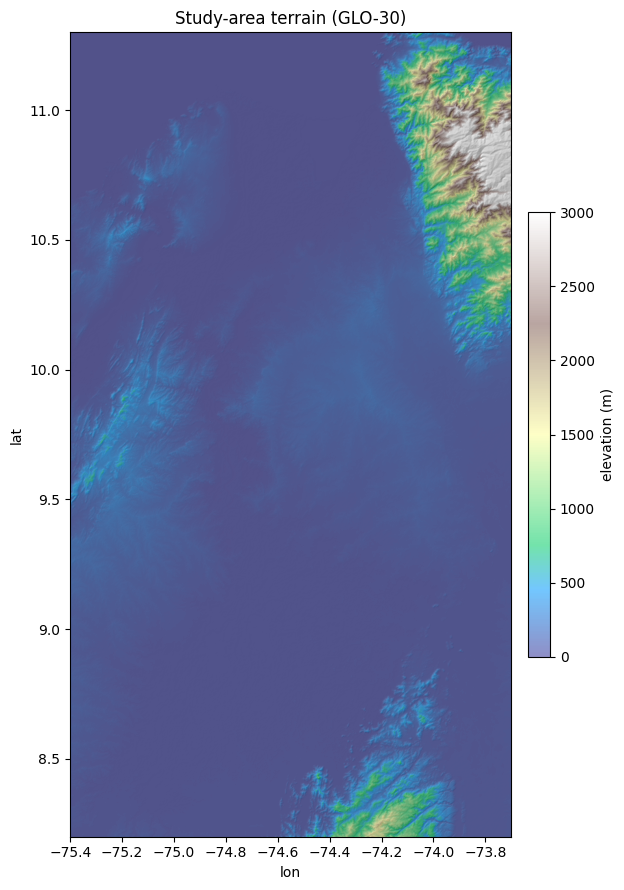

In [3]:
f = 9  # coarsen 30 m -> ~270 m just for fast display
with rasterio.open(dem_tif) as ds:
    H, W = ds.height//f, ds.width//f
    dem = ds.read(1, out_shape=(1,H,W), resampling=Resampling.average).astype("float32")
    b = ds.bounds
dem = np.where(dem < -100, np.nan, dem)
ls = LightSource(azdeg=315, altdeg=45)
fig, ax = plt.subplots(figsize=(6.5,9))
ax.imshow(ls.hillshade(np.nan_to_num(dem), vert_exag=5e-4), cmap="gray",
          extent=[b.left,b.right,b.bottom,b.top])
im = ax.imshow(dem, cmap="terrain", alpha=0.55, vmin=0, vmax=3000,
               extent=[b.left,b.right,b.bottom,b.top])
ax.set_title("Study-area terrain (GLO-30)"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="elevation (m)"); plt.tight_layout(); plt.show()


## 3. Flow accumulation — and why it fails *here*

We coarsen the DEM (for speed), fill depressions, then compute D8 flow direction and accumulation — the same chain as
notebook 01. Watch the **maximum accumulation**: for a real river it should be a large fraction of the grid. Here it
comes out tiny, which is the diagnostic.

In [5]:
from pysheds.grid import Grid
# write the coarsened DEM to a temp GeoTIFF for pysheds
tmp = os.path.join(WORK, "dem_coarse.tif")
with rasterio.open(dem_tif) as ds:
    H,W = ds.height//f, ds.width//f
    d = ds.read(1, out_shape=(1,H,W), resampling=Resampling.average).astype("float32")
    t = ds.transform * ds.transform.scale(ds.width/W, ds.height/H)
    prof = ds.profile; prof.update(height=H,width=W,transform=t,dtype="float32",nodata=-9999,count=1)
    with rasterio.open(tmp,"w",**prof) as o: o.write(d,1)

grid = Grid.from_raster(tmp); dem_g = grid.read_raster(tmp)
dem_g = grid.fill_pits(dem_g); dem_g = grid.fill_depressions(dem_g)
fdir = grid.flowdir(dem_g); acc = grid.accumulation(fdir)
cell_km2 = (270*270)/1e6
print("max accumulation:", int(np.array(acc).max()), "cells =",
      round(int(np.array(acc).max())*cell_km2), "km2   <-- far too small for a real river")


max accumulation: 1341 cells = 98 km2   <-- far too small for a real river


## 4. Findings — the box is not delineable

The tiny maximum accumulation is not a bug; it exposes two real limitations of this DEM:

1. **The upstream basin is outside the box.** The box spans only 8.2–11.3° N, but the Magdalena's catchment extends
   hundreds of km south. The mainstem therefore *enters the box from the south edge with ~0 accumulated area* — its true
   drainage area is off-map, so accumulation computed inside the box cannot identify the real river.
2. **The flat delta breaks D8.** The floodplain/delta has near-zero slope, so without slope-forcing (an ε gradient) or
   flat resolution, flow stalls in the flats and never accumulates into a channel. This is the *flats* problem of
   notebook 01 — and precisely why the lower Magdalena is modelled with floodplain/hydrodynamic routing.

**Conclusion.** The **stream-definition threshold cannot be chosen on this box.** It must be determined on a DEM that
contains the upstream catchment and the steeper terrain where D8 works — i.e. the full-basin DEM we size once the
advisor confirms the study domain.

## 5. Parameters to fix on the full-basin DEM (checklist for the redo)

When the domain is confirmed and we have the proper DEM, this same EDA gives us:

- **Stream-definition threshold** — express it as a **drainage area** (km²), not raw cells, because it's
  resolution-independent. Choose it so minibacias come out at a workable size (MGB minibacias are typically ~tens of km²).
  Convert to cells for IPH:  `threshold_cells = area_km2 / cellsize_km**2`  (at 30 m, ÷ 0.0009).
- **Fill ε (epsilon)** — a small positive value so filled flats still drain (avoids the false-pit artefact from notebook 01).
- **NoData = −9999** — force it (and mask the ocean) before exporting to `.asc` for IPH-HydroTools.

This notebook stays as the record of *why* the lower box alone can't be delineated, so the reasoning isn't rediscovered later.